# 2.7b — SMO from scratch : SVM soft-margin, boucle de Platt, KKT et gap de dualité

**Navigation** : [<< 2.7-Modeles-Non-Parametriques](2.7-Modeles-Non-Parametriques.ipynb) | [Index](README.md) | [2.8-Theorie-PAC >>](2.8-Theorie-PAC.ipynb)

**Kernel** : Python 3 · **Durée estimée** : ~45 min

## Introduction

> **Concept-phare** : un SVM soft-margin ne se résout pas par `fit()`. Le **problème dual** (maximisation sous contraintes boîtes `0 ≤ α_i ≤ C`) a une structure qui interdit les mises à jour par descente de gradient classiques : si on bouge un seul `α_i`, la contrainte `Σ α_i y_i = 0` force à en bouger un autre. La **SMO (Sequential Minimal Optimization)** de Platt (1998) exploite cette rigidité en optimisant **analytiquement** deux variables à la fois — un sous-problème 2D soluble en `O(1)`. C'est la famille d'algorithmes qu'implémente LIBSVM (la bibliothèque derrière `sklearn.svm.SVC`), avec une variante de sélection du working set (Fan, Chen & Lin, 2005) à la place des heuristiques de Platt.

**Position dans la série** : [2.7 — Modèles non paramétriques](2.7-Modeles-Non-Parametriques.ipynb) a présenté le SVM et le kernel trick comme une boîte noire (`sklearn.svm.SVC.fit`). Ce notebook **ouvre cette boîte** : on réimplémente la boucle SMO pour SVM binaire soft-margin avec noyau RBF, on la confronte à sklearn sur le même jeu de données, et on trace les diagnostics que la boîte noire cache — vecteurs supports, marges, et **gap de dualité**. Le pendant SOTA est `sklearn.svm.SVC` (noyau RBF, soft-margin) : la comparaison justifie le from-scratch (comprendre la convergence et la dualité KKT) et mesure le coût d'un solveur C optimisé.

### Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. **Dériver le dual soft-margin** d'un SVM à noyau et expliquer pourquoi la contrainte d'égalité `Σ α_i y_i = 0` interdit toute mise à jour portant sur une seule variable.
2. **Implémenter la SMO de Platt** from scratch : sous-problème 2D analytique (avec sa branche dégénérée `η ≤ 0`), cascade de sélection du working set, et mise à jour du biais `b`.
3. **Objectiver la convergence** par deux mesures indépendantes de toute horloge : le **gap de dualité** (primal moins dual) et la **violation KKT** résiduelle.
4. **Confronter** la solution from-scratch à `sklearn.svm.SVC` sur le même jeu de données : biais, score de décision, ensemble des vecteurs supports, frontière.

### Prérequis

- [2.7 — Modèles non paramétriques](2.7-Modeles-Non-Parametriques.ipynb) : SVM, marge maximale, kernel trick, vecteurs supports.
- [2.3 — Régression linéaire et logistique](2.3-Regression-lineaire-logistique.ipynb) : optimiser un objectif, interpréter un coefficient.
- [2.5 — Biais-variance, CV, ROC](2.5-Biais-Variance-CV-ROC.ipynb) : lire un compromis biais-variance sur un jeu de test.

Aucune dépendance profonde : NumPy et scikit-learn suffisent. Le sous-problème 2D est résolu par **formules closes**, sauf dans le cas dégénéré `η ≤ 0` où l'on compare les deux bornes.

> **Référence.** Platt, J. C. (1998), *Sequential Minimal Optimization: A Fast Algorithm for Training Support Vector Machines*, Technical Report MSR-TR-98-14, Microsoft Research. L'algorithme implémenté ici : décomposition en sous-problèmes de taille 2, heuristiques de sélection du working set, mise à jour du biais, critère d'arrêt. LIBSVM implémente un **variant** de cette même famille : le noyau algorithmique (sous-problèmes de taille 2) est commun, mais les règles de sélection du working set diffèrent (information du second ordre, réf. 2 ci-dessous).


In [1]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

RNG = np.random.default_rng(seed=20260914)
print(f'numpy={np.__version__}')

numpy=2.4.4


## 1. SVM soft-margin : le problème dual

Étant donné $(x_i, y_i)_{i=1}^n$ avec $y_i \in \{-1, +1\}$, le SVM soft-margin dual s'écrit :

$$
\max_{\alpha} \; W(\alpha) = \sum_i \alpha_i - \tfrac{1}{2} \sum_{i,j} \alpha_i \alpha_j y_i y_j K(x_i, x_j)
\qquad \text{s.c.} \quad 0 \le \alpha_i \le C, \quad \sum_i \alpha_i y_i = 0
$$

où $K$ est un noyau symétrique semi-défini positif (RBF : $K(x, z) = \exp(-\gamma \|x-z\|^2)$). À l'optimum, le vecteur de poids primal est $w = \sum_i \alpha_i y_i \phi(x_i)$ et le biais $b$ se déduit des points sur la marge (`0 < α_i < C`).

**Trois propriétés structurelles** que la SMO exploite :

1. **Contrainte d'égalité** : `Σ α_i y_i = 0`. Modifier un seul `α_i` la casse — il faut en modifier **au moins deux** pour la restaurer.
2. **Sous-problème 2D soluble analytiquement** : si on fixe tous les `α` sauf deux (`α_1, α_2`), la contrainte d'égalité devient une droite dans le plan `(α_1, α_2)`, intersectée avec la boîte `[0, C]²`. La maximisation de `W` le long de cette droite est **strictement concave** dès que la courbure `η = K₁₁ + K₂₂ − 2K₁₂` est `> 0` — le cas générique — et sa solution est alors close ; pour `η ≤ 0` le maximum tombe à une **borne** de l'intervalle (section 3).
3. **KKT complementarity** : à l'optimum, chaque `α_i` tombe dans l'un des trois régimes. En notant $f(x_i)$ le score de décision et $y_i f(x_i)$ la marge signée :

   - `α_i = 0` : point **hors de la marge** (ou sur la marge) — `y_i f(x_i) ≥ 1` ;
   - `0 < α_i < C` : point **sur la marge** — `y_i f(x_i) = 1` ;
   - `α_i = C` : point **dans la marge ou mal classé** (slack actif) — `y_i f(x_i) ≤ 1`.

   Ce sont ces inégalités, prises à `tol` près, que le test d'arrêt de SMO vérifie (section 5).

## 2. Noyau RBF et prédiction

Le noyau RBF $K(x, z) = \exp(-\gamma \|x-z\|^2)$ projette implicitement les données dans un espace de dimension infinie. On l'implémente directement comme matrice de Gram — pour $n$ raisonnable (≤ 500), c'est $O(n^2)$ en mémoire, $O(n^2 \cdot d)$ en calcul.

In [2]:
def rbf_kernel(X, Z, gamma):
    """Matrice de Gram RBF K[i, j] = exp(-gamma * ||X[i] - Z[j]||^2).

    Parameters
    ----------
    X : (n, d) array
    Z : (m, d) array
    gamma : scalaire positif (1 / (2 * sigma^2))
    """
    sq_X = (X ** 2).sum(axis=1)[:, None]   # (n, 1)
    sq_Z = (Z ** 2).sum(axis=1)[None, :]   # (1, m)
    dist2 = sq_X + sq_Z - 2.0 * X @ Z.T
    np.maximum(dist2, 0.0, out=dist2)  # évite -0.0 sous-jacent
    return np.exp(-gamma * dist2)


def predict_raw(X, support_X, support_y, support_alpha, b, gamma):
    """Score de décision f(x) = Σ_{i in SV} α_i y_i K(x, x_i) + b.

    Retourne le score brut (signe = classe prédite).
    """
    K = rbf_kernel(X, support_X, gamma)
    return K @ (support_alpha * support_y) + b


def predict(X, support_X, support_y, support_alpha, b, gamma):
    return np.sign(predict_raw(X, support_X, support_y, support_alpha, b, gamma))

# --- auto-controle des proprietes que la dualite suppose du noyau ---
_Xs = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 2.0]])
_K = rbf_kernel(_Xs, _Xs, gamma=0.5)
print(f'symetrie K == K.T     : {np.allclose(_K, _K.T)}')
print(f'diagonale K(x, x) = 1 : {np.allclose(np.diag(_K), 1.0)}')
print(f'valeurs dans ]0, 1]   : {bool((_K > 0).all() and (_K <= 1.0 + 1e-12).all())}')
print(f'valeur propre min     : {np.linalg.eigvalsh(_K).min():.3e}  (>= 0 : noyau semi-defini positif)')
print(f'K a distance 100      : {rbf_kernel(np.array([[0.0, 0.0]]), np.array([[100.0, 0.0]]), 0.5)[0, 0]:.3e}  (influence locale)')


symetrie K == K.T     : True
diagonale K(x, x) = 1 : True
valeurs dans ]0, 1]   : True
valeur propre min     : 3.911e-01  (>= 0 : noyau semi-defini positif)
K a distance 100      : 0.000e+00  (influence locale)


## 3. Le sous-problème 2D : solution analytique de Platt

On fixe tous les `α` sauf deux : `α_1` et `α_2`. La contrainte d'égalité `Σ α_i y_i = 0` impose :

$$
\alpha_1 y_1 + \alpha_2 y_2 = c \quad \text{où} \quad c = -\sum_{i \ne 1, 2} \alpha_i y_i
$$

On élimine `α_1 = y_1 (c - α_2 y_2)` (car $y_1 \in \{-1, +1\}$, $y_1^2 = 1$), on reporte dans $W(\alpha)$ et on dérive. Le long de la contrainte, `W` n'est plus qu'une **fonction quadratique d'une seule variable** `α_2`, de courbure

$$
\eta = K_{11} + K_{22} - 2 K_{12} = \|\phi(x_1) - \phi(x_2)\|^2
$$

(pour tout noyau valide, l'écriture de droite est exacte — elle développe $K_{11} + K_{22} - 2K_{12}$ ; et comme $K_{12} \le \sqrt{K_{11} K_{22}}$ par Cauchy–Schwarz, on a $\eta \ge 0$). Deux cas :

- **`η > 0`** (générique) : `W` est **strictement concave** en `α_2` et son maximum est intérieur. La dérivée nulle donne la formule close

  $$
  \alpha_2^{new, unc} = \alpha_2^{old} + \frac{y_2 (E_1 - E_2)}{\eta}
  $$

  où $E_i = f(x_i) - y_i$ est l'erreur courante sur l'exemple $i$. On clippe ensuite dans `[L, H]` — les bornes de la boîte `[0, C]²` le long de la contrainte, qui dépendent du signe de $y_1 y_2$.

- **`η ≤ 0`** : `W` est **affine** (`η = 0`) ou **convexe** (`η < 0`) en `α_2`, donc son maximum sur `[L, H]` est atteint à une **borne**. On compare l'objectif dual aux deux bornes et on garde la meilleure. Diviser par `η` (ou par un `max(η, ε)` de garde) produirait un pas arbitrairement grand, dans une direction qui ne caractérise plus le maximum.

`η = 0` correspond à deux points **confondus** dans l'espace des features (`φ(x_1) = φ(x_2)`) : le cas se produit avec des doublons exacts dans le jeu d'entraînement. Un `η < 0` est **impossible pour un noyau valide** (Cauchy–Schwarz) : la branche existe pour la robustesse numérique, et le bloc d'auto-contrôle de la section 6 la teste sur un état fabriqué.

Une fois `α_2^{new}` choisi, `α_1^{new}` se déduit de la contrainte d'égalité.

## 4. Heuristique de Platt : choisir le working set de 2 variables

La boucle externe balaie **chaque exemple `i`** ; pour ceux qui violent les KKT, elle tente de former une paire de travail (`i`, `j`) en **deux tentatives** :

1. **Candidat non-borné** : parmi les exemples **non bornés** (`0 < α_j < C`), prendre celui qui maximise `|E_i - E_j|` — le mouvement attendu le plus ample. C'est l'heuristique 1 de Platt.
2. **Balayage complet** : si la première tentative ne fait pas progresser `α`, balayer **tous** les `j ≠ i` dans l'ordre. Cela garantit qu'aucune violation KKT ne reste inexplorée faute de candidat non borné.

> **Pourquoi deux tentatives, et pas trois.** Platt décrit une heuristique 2 qui rejoue le balayage des non-bornés — mais sa boucle externe balaie **déjà** tous les exemples comme `i`, non-bornés compris. Une seconde passe sur les non-bornés rejoue exactement le même candidat que la tentative 1 : le même `np.where((α > 0) & (α < C))`, le même `argmax |E_i − E_j|`. Son seul effet serait de retenter une paire qui vient d'échouer. La cascade implémentée ici **omet ce doublon** — une tentative non-borné, puis le balayage complet. Le comportement est identique (un `_take_step` qui échoue ne modifie ni `α` ni `b`), le code est plus court.

Le critère d'arrêt de la **boucle externe** est un compteur `passes` (un passage = un balayage complet des `n` exemples). `passes` s'incrémente quand **aucune paire n'a fait progresser `α`** sur le passage ; au-delà de `max_passes` passages sans progrès, l'algorithme s'arrête. Le compteur `n_iter` retourné par `smo_fit` compte les **appels à `examine_example`** — soit `n` par passe effectuée, pas le nombre de mises à jour réussies.

## 5. Critère d'arrêt : violation KKT, garde `eps` et compteur de passes

Le test « cet exemple viole-t-il les KKT ? » repose sur un **résidu signé unique**. Posons

$$
r_i \;=\; y_i E_i \;=\; y_i \bigl(f(x_i) - y_i\bigr) \;=\; y_i f(x_i) - 1
$$

c'est-à-dire la marge signée moins `1`. Les trois régimes KKT de la section 1 s'écrivent alors sur `r_i` seul : `r_i ≥ 0` si `α_i = 0`, `r_i = 0` si `0 < α_i < C`, `r_i ≤ 0` si `α_i = C`. Le test implémenté est :

- violation si `r_i < -tol` **et** `α_i < C` — un point sous la marge qui peut encore monter ;
- violation si `r_i > +tol` **et** `α_i > 0` — un point au-dessus de la marge qui peut encore descendre.

Trois mécanismes distincts gouvernent l'arrêt, tous **locaux** à la boucle :

1. ce **test KKT** par exemple, avec la tolérance `tol` ;
2. une **garde `eps`** par pas : `_take_step` refuse une mise à jour dont le déplacement de `α_j` est inférieur à `eps × (α_j + eps)` — elle évite de boucler sur des pas numériquement nuls ;
3. le **compteur `max_passes`** : la boucle s'arrête après `max_passes` balayages complets sans aucune mise à jour acceptée.

Aucun des trois ne mesure la distance à l'optimum : ils bornent des **mouvements locaux**. Deux mesures plus fortes, calculables une fois la boucle terminée, sont détaillées en **section 10** — le **gap de dualité** (primal moins dual) et la **violation KKT** résiduelle — et chiffrent ce que ces critères laissent sur la table.


## 6. Implémentation SMO from scratch

On assemble : sous-problème 2D analytique (avec sa branche dégénérée `η ≤ 0`), cascade de sélection du working set à deux tentatives, garde `eps` par pas et compteur `max_passes`. La sortie est un SVM prêt à prédire (vecteurs de support, `α`, biais `b`).

La cellule inclut deux **auto-contrôles** exécutés après les définitions :

- **A** — un jeu jouet linéairement séparable vérifie que le biais appris est cohérent avec la solution duale : sur les points non bornés, l'écart `|y_k f(x_k) − 1|` doit être petit, et il **explose** si l'on force `b = 0` ;
- **B** — la branche `η ≤ 0` est validée sur trois points : le raccourci 2D égale l'objectif dual complet, une paire de points confondus donne bien `η = 0`, et sur un état `η < 0` fabriqué la comparaison aux bornes sélectionne le **maximum** de l'objectif.

In [3]:
def _dual_obj_2d(alpha_j, c, yi, yj, vi, vj, Kii, Kjj, Kij):
    """Objectif dual W restreint au sous-probleme (i, j), en fonction de alpha_j.

    alpha_i est elimine par la contrainte d'egalite (alpha_i y_i + alpha_j y_j = c),
    et v_i = sum_{k != i, j} alpha_k y_k K(x_i, x_k) (idem pour j). Ne restent que
    les termes de W qui couplent les deux variables ; les autres sont constants et
    s'annulent des lors qu'on compare deux valeurs de alpha_j.
    """
    s = yi * yj
    alpha_i = yi * (c - alpha_j * yj)
    return (alpha_i + alpha_j
            - 0.5 * (Kii * alpha_i * alpha_i + Kjj * alpha_j * alpha_j
                     + 2.0 * s * Kij * alpha_i * alpha_j)
            - alpha_i * yi * vi - alpha_j * yj * vj)


def _take_step(i, j, y, alpha, b, K, C, tol, eps, E_cache):
    """Sous-probleme 2D analytique (Platt, eq. 12.7-12.11).

    Tente de mettre a jour (alpha[i], alpha[j]). Retourne (changed, b_new).
    Si pas de progres : retourne (0, b) sans modification.
    """
    if i == j:
        return 0, b
    alpha_i_old = alpha[i].copy()
    alpha_j_old = alpha[j].copy()
    yi, yj = y[i], y[j]
    # bornes L, H imposees par 0 <= alpha <= C et alpha_i y_i + alpha_j y_j = const
    if yi != yj:
        L = max(0.0, alpha[j] - alpha[i])
        H = min(C, C + alpha[j] - alpha[i])
    else:
        L = max(0.0, alpha[i] + alpha[j] - C)
        H = min(C, alpha[i] + alpha[j])
    if L >= H:
        return 0, b
    Kii, Kjj, Kij = K[i, i], K[j, j], K[i, j]
    s = yi * yj
    # courbure de W le long de la contrainte : eta = ||phi(x_i) - phi(x_j)||^2 >= 0
    eta = Kii + Kjj - 2.0 * Kij
    if eta > 0:
        # W est strictement concave en alpha_j : maximum interieur -> formule close
        alpha_j_new = alpha_j_old + yj * (E_cache[i] - E_cache[j]) / eta
        alpha_j_new = min(H, max(L, alpha_j_new))
    else:
        # eta <= 0 : W est affine (eta = 0) ou convexe (eta < 0) en alpha_j, donc son
        # maximum sur [L, H] est atteint a une BORNE. Platt (1998, App. A) evalue
        # l'objectif aux deux bornes et retient la meilleure. Diviser par eta (ou par
        # un max(eta, 1e-12)) donnerait un pas arbitrairement grand, dans une
        # direction qui ne caracterise plus le maximum.
        c = alpha_i_old * yi + alpha_j_old * yj
        vi = E_cache[i] + yi - b - alpha_i_old * yi * Kii - alpha_j_old * yj * Kij
        vj = E_cache[j] + yj - b - alpha_j_old * yj * Kjj - alpha_i_old * yi * Kij
        W_L = _dual_obj_2d(L, c, yi, yj, vi, vj, Kii, Kjj, Kij)
        W_H = _dual_obj_2d(H, c, yi, yj, vi, vj, Kii, Kjj, Kij)
        if W_L > W_H:
            alpha_j_new = L
        elif W_L < W_H:
            alpha_j_new = H
        else:
            alpha_j_new = alpha_j_old       # objectif plat : aucun mouvement utile
    if abs(alpha_j_new - alpha_j_old) < eps * (alpha_j_old + eps):
        return 0, b
    alpha_i_new = alpha_i_old + s * (alpha_j_old - alpha_j_new)
    # mettre a jour alpha
    alpha[i] = alpha_i_new
    alpha[j] = alpha_j_new
    # recalculer b (Platt eq. 12.7-12.8)
    b1 = b - E_cache[i] - yi * (alpha_i_new - alpha_i_old) * Kii - yj * (alpha_j_new - alpha_j_old) * Kij
    b2 = b - E_cache[j] - yi * (alpha_i_new - alpha_i_old) * Kij - yj * (alpha_j_new - alpha_j_old) * Kjj
    if 0 < alpha_i_new < C:
        b_new = b1
    elif 0 < alpha_j_new < C:
        b_new = b2
    else:
        b_new = 0.5 * (b1 + b2)
    # mettre a jour le cache d'erreurs : E_k = sum_l alpha_l y_l K_lk + b - y_k
    delta_i = alpha_i_new - alpha_i_old
    delta_j = alpha_j_new - alpha_j_old
    E_cache += yi * delta_i * K[:, i] + yj * delta_j * K[:, j]
    # le nouveau biais decale TOUTES les erreurs cachees de (b_new - b)
    E_cache += (b_new - b)
    return 1, b_new


def smo_fit(X, y, C=1.0, gamma=1.0, tol=1e-3, max_passes=20, eps=1e-3, verbose=False):
    """SMO de Platt pour SVM binaire soft-margin avec noyau RBF.

    Parametres
    ----------
    X : (n, d) array d'entrainement
    y : (n,) array d'etiquettes dans {-1, +1}
    C : parametre de soft-margin (slack penalty)
    gamma : parametre du noyau RBF
    tol : tolerance du test KKT par exemple (section 5)
    max_passes : nombre max de passes completes sans changement
    eps : tolerance relative de rejet d'un pas sur alpha_j

    Retourne
    --------
    dict avec cles : alpha (n,), b (scalaire), support_mask (bool n,),
    n_iter (int, nombre d'appels a examine_example -- n par passe effectuee)
    """
    n = X.shape[0]
    alpha = np.zeros(n)
    b = 0.0
    K = rbf_kernel(X, X, gamma)
    # cache d'erreurs E[i] = sum_j alpha_j y_j K[j,i] + b - y[i]
    E_cache = -y.copy()

    def examine_example(i):
        """Tente un pas sur l'exemple i : test KKT, puis cascade de Platt.

        Le biais est une variable d'etat de smo_fit : chaque pas qui progresse
        le met a jour, et le sous-probleme suivant doit repartir de la nouvelle
        valeur (sinon les erreurs cachees E sont decalees de b, et la solution
        duale converge vers un modele dont le score de decision est biaise).
        """
        nonlocal b
        Ei = E_cache[i]
        yi = y[i]
        ri = yi * Ei                    # ri = y_i (f(x_i) - y_i) = y_i f(x_i) - 1
        # KKT : alpha=0 => r>=0, 0<alpha<C => r=0, alpha=C => r<=0 (a tol pres)
        violates = (ri < -tol and alpha[i] < C) or (ri > tol and alpha[i] > 0)
        if not violates:
            return 0
        # Heuristique 1 de Platt : parmi les exemples NON BORNES (0 < alpha_j < C),
        # prendre celui qui maximise |Ei - Ej| (le mouvement attendu le plus ample).
        non_bound = np.where((alpha > 0) & (alpha < C))[0]
        non_bound = non_bound[non_bound != i]
        if len(non_bound) > 0:
            j = non_bound[np.argmax(np.abs(E_cache[non_bound] - Ei))]
            ok, b = _take_step(i, j, y, alpha, b, K, C, tol, eps, E_cache)
            if ok:
                return 1
        # Heuristique 2 (balayage complet) : tous les j != i, dans l'ordre. Garantit
        # qu'aucune violation KKT ne reste inexploree faute de candidat non borne.
        for j in range(n):
            if j == i:
                continue
            ok, b = _take_step(i, j, y, alpha, b, K, C, tol, eps, E_cache)
            if ok:
                return 1
        return 0

    passes = 0
    n_iter = 0
    while passes < max_passes:
        num_changed = 0
        # --- balayage complet des n exemples ---
        for i in range(n):
            n_iter += 1
            if examine_example(i):
                num_changed += 1
        if num_changed == 0:
            passes += 1
        else:
            passes = 0
        if verbose:
            print(f'  passe={passes}, num_changed={num_changed}, |SV|={(alpha > 1e-6).sum()}')

    support_mask = alpha > 1e-6
    return {
        'alpha': alpha,
        'b': float(b),
        'support_mask': support_mask,
        'n_iter': n_iter,
    }


# --- auto-controle A : le biais appris est-il celui de la solution duale ? ---
# Jeu jouet lineairement separable (droite x1 + x2 = 1) : 4 points negatifs,
# 2 positifs. A l'optimum, tout point tel que 0 < alpha_k < C est SUR la marge,
# donc doit verifier y_k f(x_k) = 1 -- une condition qui echoue si b reste a 0.
_Xs = np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0], [2.0, 2.0], [3.0, 2.0]])
_ys = np.array([-1.0, -1.0, -1.0, -1.0, 1.0, 1.0])
_m = smo_fit(_Xs, _ys, C=1.0, gamma=1.0, tol=1e-4, max_passes=20)
_sm = _m['support_mask']
_on_margin = (_m['alpha'] > 1e-6) & (_m['alpha'] < 1.0 - 1e-6)
_f = predict_raw(_Xs, _Xs[_sm], _ys[_sm], _m['alpha'][_sm], _m['b'], 1.0)
_ecart = np.abs(_ys[_on_margin] * _f[_on_margin] - 1.0).max() if _on_margin.any() else float('nan')
_ecart_b0 = np.abs(_ys[_on_margin] * (_f[_on_margin] - _m['b']) - 1.0).max() if _on_margin.any() else float('nan')
print(f'test jouet : b appris = {_m["b"]:+.4f}, |SV| = {_sm.sum()}/{len(_ys)}, n_iter = {_m["n_iter"]}')
print(f'test jouet : ecart max |y_k f(x_k) - 1| sur les non-bornees = {_ecart:.2e}')
print(f"test jouet : le meme ecart si l'on force b = 0            = {_ecart_b0:.2e}")


# --- auto-controle B : la branche eta <= 0 doit MAXIMISER l'objectif dual ---
# Un noyau valide verifie K_ij <= sqrt(K_ii K_jj) (Cauchy-Schwarz), donc
# eta = K_ii + K_jj - 2 K_ij = ||phi_i - phi_j||^2 >= 0 : le regime eta <= 0 ne se
# rencontre qu'avec des points CONFONDUS (eta = 0 exact) ou du bruit flottant. On
# teste donc separement (1) que le raccourci 2D de la branche egale l'objectif dual
# complet, (2) qu'une paire confondue donne bien eta = 0, et (3) que la comparaison
# aux bornes maximise reellement -- sur un etat eta < 0 fabrique pour cibler
# l'arithmetique (aucun etat a noyau valide ne le produit).
def _W_full(alpha, yy, KK):
    """Objectif dual complet, recalcule SANS _dual_obj_2d (reference independante)."""
    ay = alpha * yy
    return float(alpha.sum() - 0.5 * ay @ KK @ ay)


# (1) etat reel coherent : le raccourci 2D doit egaler l'objectif complet
_rng = np.random.default_rng(7)
_Xw = _rng.normal(size=(7, 3))
_yw = np.where(_rng.random(7) > 0.5, 1.0, -1.0)
_Kw = rbf_kernel(_Xw, _Xw, 1.7)
_aw = np.round(_rng.random(7) * 0.5, 3)
_bw = 0.23
_Ew = (_Kw @ (_aw * _yw) + _bw) - _yw
_i, _j = 2, 5
_c = _aw[_i] * _yw[_i] + _aw[_j] * _yw[_j]
_vi = _Ew[_i] + _yw[_i] - _bw - _aw[_i] * _yw[_i] * _Kw[_i, _i] - _aw[_j] * _yw[_j] * _Kw[_i, _j]
_vj = _Ew[_j] + _yw[_j] - _bw - _aw[_j] * _yw[_j] * _Kw[_j, _j] - _aw[_i] * _yw[_i] * _Kw[_i, _j]
_w0 = _dual_obj_2d(_aw[_j], _c, _yw[_i], _yw[_j], _vi, _vj, _Kw[_i, _i], _Kw[_j, _j], _Kw[_i, _j])
_ecart_2d = 0.0
for _t in (0.0, 0.17, 0.41, 0.66):
    _a2 = _aw.copy()
    _a2[_j] = _t
    _a2[_i] = _yw[_i] * (_c - _t * _yw[_j])          # contrainte d'egalite respectee
    _ecart_2d = max(_ecart_2d,
                    abs((_W_full(_a2, _yw, _Kw) - _W_full(_aw, _yw, _Kw))
                        - (_dual_obj_2d(_t, _c, _yw[_i], _yw[_j], _vi, _vj,
                                        _Kw[_i, _i], _Kw[_j, _j], _Kw[_i, _j]) - _w0)))
assert _ecart_2d < 1e-10, _ecart_2d
print(f'branche eta<=0 : raccourci 2D == objectif dual complet (ecart max {_ecart_2d:.1e})')

# (2) eta = 0 est atteignable avec un noyau RBF : deux points confondus
_Xp = np.array([[0.0, 0.0], [0.0, 0.0], [2.0, 1.0]])
_Kp = rbf_kernel(_Xp, _Xp, 1.0)
_eta_dup = _Kp[0, 0] + _Kp[1, 1] - 2.0 * _Kp[0, 1]
print(f'branche eta<=0 : deux points confondus -> eta = {_eta_dup:.1e} (cas reel de la branche)')

# (3) etat eta < 0 fabrique : le maximum doit tomber sur une borne, sans pas arbitraire
_Kd = np.array([[1.0, 1.5], [1.5, 1.0]])
_yd = np.array([1.0, 1.0])
for _Ed in (np.array([0.05, 0.0]), np.array([0.0, 0.0])):
    _ad = np.array([0.05, 0.95])
    _take_step(0, 1, _yd, _ad, 0.0, _Kd, 1.0, 1e-3, 1e-3, _Ed.copy())
    _grille = np.linspace(0.0, 1.0, 20001)
    _vals = np.array([_W_full(np.array([1.0 - _t, _t]), _yd, _Kd) for _t in _grille])
    _argmax = _grille[_vals.argmax()]
    print(f'branche eta<0 : E={_Ed} -> alpha_j choisi = {_ad[1]:.2f}, argmax de l objectif = {_argmax:.2f}')
    assert abs(_ad[1] - _argmax) < 1e-3, (_ad[1], _argmax)
print('branche eta<=0 : OK (maximum pris a une borne)')

test jouet : b appris = -0.1915, |SV| = 6/6, n_iter = 150
test jouet : ecart max |y_k f(x_k) - 1| sur les non-bornees = 4.60e-04
test jouet : le meme ecart si l'on force b = 0            = 1.92e-01
branche eta<=0 : raccourci 2D == objectif dual complet (ecart max 5.6e-17)
branche eta<=0 : deux points confondus -> eta = 0.0e+00 (cas reel de la branche)


branche eta<0 : E=[0.05 0.  ] -> alpha_j choisi = 0.00, argmax de l objectif = 0.00


branche eta<0 : E=[0. 0.] -> alpha_j choisi = 0.00, argmax de l objectif = 0.00
branche eta<=0 : OK (maximum pris a une borne)


## 7. Évaluation : make_moons binaire

On reprend le dataset `make_moons` qu'utilisait [2.7](2.7-Modeles-Non-Parametriques.ipynb) (les deux croissants non linéairement séparables), split train/test, et on entraîne un SVM RBF.

**Hyperparamètres** : `C = 1.0` (slack penalty modéré), `gamma = 2.0` (noyau RBF tight, frontière sinueuse). Ces choix ne sont pas optimaux — l'objet de cette section est la **validation** (accuracy et nombre de support vectors) contre sklearn, pas le tuning.

Le compteur `n_iter` affiché ci-dessous compte les **appels à `examine_example`** (soit `n` par passe effectuée), pas les mises à jour réussies : un grand `n_iter` pour peu de progrès signale des passes de balayage infructueuses — c'est le comportement attendu en fin de convergence, où plus rien ne viole les KKT.

In [4]:
X, y_pm = make_moons(n_samples=200, noise=0.25, random_state=42)
y = np.where(y_pm == 0, -1, 1).astype(float)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

C = 1.0
gamma = 2.0

t0 = time.perf_counter()
model = smo_fit(X_tr, y_tr, C=C, gamma=gamma, tol=1e-3, max_passes=20, verbose=False)
t_smo = time.perf_counter() - t0

support_X = X_tr[model['support_mask']]
support_y = y_tr[model['support_mask']]
support_alpha = model['alpha'][model['support_mask']]

y_pred_smo = predict(X_te, support_X, support_y, support_alpha, model['b'], gamma)
acc_smo = accuracy_score(y_te, y_pred_smo)

print(f'SMO from-scratch : accuracy test = {acc_smo:.3f}, n_iter = {model["n_iter"]}, |SV| = {model["support_mask"].sum()}, temps = {t_smo:.2f}s')

# --- comparaison sklearn SVC (kernel RBF, mêmes hyperparamètres) ---
t0 = time.perf_counter()
clf = SVC(C=C, kernel='rbf', gamma=gamma, tol=1e-3, max_iter=20000)
clf.fit(X_tr, y_tr)
t_skl = time.perf_counter() - t0

acc_skl = accuracy_score(y_te, clf.predict(X_te))

print(f'sklearn SVC      : accuracy test = {acc_skl:.3f}, |SV| = {clf.n_support_.sum()},      temps = {t_skl:.2f}s')
print(f'écart accuracy    : {abs(acc_smo - acc_skl):.3f}')

SMO from-scratch : accuracy test = 0.967, n_iter = 21560, |SV| = 48, temps = 1.19s
sklearn SVC      : accuracy test = 0.967, |SV| = 48,      temps = 0.00s
écart accuracy    : 0.000


### Exercice 1 : l'effet du paramètre `C` sur le nombre de vecteurs supports

Le paramètre `C` arbitre entre marge large et pénalité des erreurs : un **petit `C`** accepte des violations de marge (frontière souple), un **grand `C`** les pénalise durement (frontière resserrée, davantage de points retenus par le modèle). La section 7 fixe `C = 1.0` sans justifier ce choix ; cet exercice mesure ce que `C` change réellement.

**Objectif** : pour `C ∈ {0.1, 1.0, 10.0}`, entraîner `smo_fit` sur `X_tr`/`y_tr` (mêmes `gamma`, `tol`, `max_passes`), puis tracer le nombre de vecteurs supports `|SV|` **et** l'accuracy de test en fonction de `C`.

**Indice** : réutilisez `predict` et `accuracy_score` ; stockez les deux séries dans des listes de même longueur que la grille de `C`, puis un `plt.plot` par série (échelle log en `x` : `ax.set_xscale('log')`). Comme le solveur de la section 7 est déterministe, deux exécutions donnent exactement la même courbe.


In [5]:
# Exercice 1 : effet du parametre C sur le nombre de vecteurs supports et l'accuracy
valeurs_C = [0.1, 1.0, 10.0]
n_sv_par_C = None   # TODO etudiant : remplacer (liste des |SV| pour chaque valeur de C)
acc_par_C = None    # TODO etudiant : remplacer (liste des accuracies de test pour chaque C)

# TODO etudiant : pour chaque C de valeurs_C :
#   - appeler smo_fit(X_tr, y_tr, C=c, gamma=gamma, tol=1e-3, max_passes=20)
#   - compter les vecteurs supports : modele['support_mask'].sum()
#   - predire sur X_te via predict(...) et mesurer accuracy_score(y_te, ...)
#   - tracer les deux series en fonction de C (echelle log en x)
print(f"Exercice 1 a completer : |SV| par C = {n_sv_par_C}, accuracy par C = {acc_par_C}")


Exercice 1 a completer : |SV| par C = None, accuracy par C = None


## 8. Diagnostics : support vectors et marges

À l'optimum SMO, les `α_i` se répartissent en trois groupes :

- `α_i = 0` : exemple non-support (loi de dualité). On peut retirer ces points sans changer la solution.
- `0 < α_i < C` : sur la marge (`y_i f(x_i) = 1`). Le biais `b` se déduit de ces points.
- `α_i = C` : support biaisé (slack actif). L'exemple est dans la marge violée ou au-delà.

**Frontière + marges** : on trace `f(x) = 0` (frontière), `f(x) = ±1` (les deux marges), et les points d'entraînement colorés par leur statut `α`.

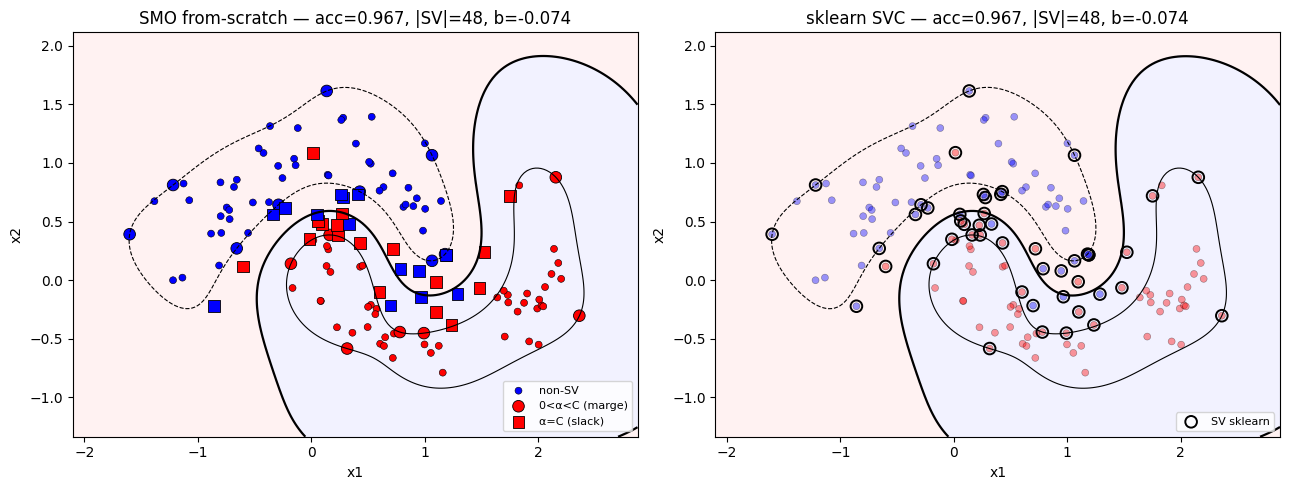

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- SMO from-scratch ---
ax = axes[0]
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
                     np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z_smo = predict_raw(grid, support_X, support_y, support_alpha, model['b'], gamma).reshape(xx.shape)
ax.contourf(xx, yy, np.sign(Z_smo), alpha=0.15, levels=[-1, 0, 1], colors=['#FFAAAA', '#AAAAFF'])
ax.contour(xx, yy, Z_smo, levels=[-1.0, 0.0, 1.0], colors='k', linewidths=[0.8, 1.6, 0.8])

alpha_all = model['alpha']
non_sv = (alpha_all <= 1e-6)
on_margin = (alpha_all > 1e-6) & (alpha_all < C - 1e-6)
at_C = (alpha_all >= C - 1e-6)
ax.scatter(X_tr[non_sv, 0], X_tr[non_sv, 1], c=y_tr[non_sv], cmap='bwr', s=25, marker='o', edgecolor='k', linewidth=0.4, label='non-SV')
ax.scatter(X_tr[on_margin, 0], X_tr[on_margin, 1], c=y_tr[on_margin], cmap='bwr', s=70, marker='o', edgecolor='k', linewidth=0.6, label='0<α<C (marge)')
ax.scatter(X_tr[at_C, 0], X_tr[at_C, 1], c=y_tr[at_C], cmap='bwr', s=70, marker='s', edgecolor='k', linewidth=0.6, label='α=C (slack)')
ax.set_title(f'SMO from-scratch — acc={acc_smo:.3f}, |SV|={model["support_mask"].sum()}, b={model["b"]:+.3f}')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend(loc='lower right', fontsize=8)

# --- sklearn ---
ax = axes[1]
Z_skl = clf.decision_function(grid).reshape(xx.shape)
ax.contourf(xx, yy, np.sign(Z_skl), alpha=0.15, levels=[-1, 0, 1], colors=['#FFAAAA', '#AAAAFF'])
ax.contour(xx, yy, Z_skl, levels=[-1.0, 0.0, 1.0], colors='k', linewidths=[0.8, 1.6, 0.8])
ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap='bwr', s=25, marker='o', edgecolor='k', linewidth=0.4, alpha=0.4)
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
           s=70, facecolors='none', edgecolors='k', linewidths=1.4, label='SV sklearn')
ax.set_title(f'sklearn SVC — acc={acc_skl:.3f}, |SV|={clf.n_support_.sum()}, b={clf.intercept_[0]:+.3f}')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('assets/readme/ml27b-smo-frontiere.png', dpi=110, bbox_inches='tight')
plt.show()


## 9. Validation : SMO et sklearn trouvent-ils les mêmes supports ?

Les deux solveurs **diffèrent par l'implémentation** (C contre Python ; LIBSVM sélectionne son working set par information du second ordre — Fan, Chen & Lin, 2005 — là où ce notebook suit les heuristiques de Platt). L'optimum du SVM dual est en revanche **unique sous conditions** : pour un noyau RBF, la matrice de Gram est **définie positive** dès que les échantillons sont deux à deux distincts, donc `W` est **strictement concave** sur l'ensemble faisable convexe et son maximiseur `α*` est unique.

« Unique sous conditions » est ici essentiel : deux solveurs **arrêtés avant** l'optimum (sur `tol`, `max_iter`, ou un compteur de passes) rendent des points différents sans que l'un soit faux. La condition porte sur le **problème** (Gram définie positive) ; elle ne dit rien de la **trajectoire** des solveurs, et rien ne garantit *a priori* que deux solveurs qui s'arrêtent tous deux « tôt » s'arrêtent au même endroit.

Ce que la cellule ci-dessous mesure est donc un **recoupement empirique**, pas un certificat universel. Un accord fort (supports identiques, écart de score petit) *suggère* que les deux solveurs ont convergé vers le même optimum ; un accord faible aurait signalé qu'au moins l'un des deux a terminé loin du sien — sans dire lequel. On compare les **scores de décision** sur un échantillon de test : leur différence `|f_smo(x) - f_skl(x)|` en est la mesure.

In [7]:
f_smo_test = predict_raw(X_te, support_X, support_y, support_alpha, model['b'], gamma)
f_skl_test = clf.decision_function(X_te)

score_diff = np.abs(f_smo_test - f_skl_test)

print(f'  biais appris (SMO)        = {model["b"]:+.4f}')
print(f'  biais sklearn (intercept) = {clf.intercept_[0]:+.4f}')
print(f'  écart |b_SMO - b_sklearn|  = {abs(model["b"] - clf.intercept_[0]):.4f}')
print(f'  max |Δf(x)|  sur test     = {score_diff.max():.4f}')
print(f'  mean |Δf(x)| sur test     = {score_diff.mean():.4f}')
print(f'  accuracy SMO  vs sklearn  = {acc_smo:.3f} / {acc_skl:.3f}')
print(f'  prédictions identiques    = {(np.sign(f_smo_test) == np.sign(f_skl_test)).mean():.3f}')

f_smo_train = predict_raw(X_tr, support_X, support_y, support_alpha, model['b'], gamma)
train_diff = np.abs(f_smo_train - clf.decision_function(X_tr))
print(f'  max |Δf(x)|  sur train    = {train_diff.max():.4f}')

intersection_sv = (model['support_mask'] & np.isin(np.arange(len(y_tr)), clf.support_)).sum()
union_sv = (model['support_mask'] | np.isin(np.arange(len(y_tr)), clf.support_)).sum()
print(f'  Jaccard supports SMO ∩ sklearn = {intersection_sv / max(union_sv, 1):.3f}')


  biais appris (SMO)        = -0.0737
  biais sklearn (intercept) = -0.0741
  écart |b_SMO - b_sklearn|  = 0.0004
  max |Δf(x)|  sur test     = 0.0049
  mean |Δf(x)| sur test     = 0.0012
  accuracy SMO  vs sklearn  = 0.967 / 0.967
  prédictions identiques    = 1.000
  max |Δf(x)|  sur train    = 0.0050
  Jaccard supports SMO ∩ sklearn = 1.000


### Exercice 2 : calculer le biais depuis tous les points non bornés

Dans `_take_step`, le biais est choisi **en cascade** : `b1` si `0 < α_i < C`, sinon `b2` si `0 < α_j < C`, sinon la demi-somme `0.5 × (b1 + b2)`. Or les conditions de KKT donnent une estimation **indépendante** de `b` par point non borné : pour tout `k` tel que `0 < α_k < C`, on a `y_k f(x_k) = 1`, donc

$$b_k = y_k - \sum_{j \in SV} \alpha_j y_j K(x_k, x_j)$$

À l'optimum ces `b_k` devraient coïncider ; les moyenner est la version stable (Platt, §12.3).

**Objectif** : calculer `b_stable` comme la **moyenne des `b_k`** sur tous les `0 < α_k < C`, puis vérifier que l'accuracy de test et le biais obtenu restent proches de `model['b']` (section 9).

**Indice** : `b_k` s'obtient directement sans le biais courant — `predict_raw(X_tr, support_X, support_y, support_alpha, 0.0, gamma)` donne `f(x_k)` privé de `b`, d'où `b_k = y_tr[k] - f_sans_biais[k]`. Si aucun point n'est non borné, la variance des `b_k` est nulle : le signaler au lieu de moyenner une liste vide.


In [8]:
# Exercice 2 : biais moyenne sur tous les points non bornes (0 < alpha < C)
b_stable = None    # TODO etudiant : remplacer (moyenne des b_k sur les 0 < alpha_k < C)
acc_stable = None  # TODO etudiant : remplacer (accuracy de test obtenue avec ce biais)

# TODO etudiant :
#   1. f_sans_biais = predict_raw(X_tr, support_X, support_y, support_alpha, 0.0, gamma)
#   2. b_k = y_tr[k] - f_sans_biais[k] pour les k tels que 0 < alpha_k < C
#   3. b_stable = b_k.mean()
#   4. re-predire sur X_te avec b=b_stable et mesurer l'accuracy
print(f"Exercice 2 a completer : b_stable = {b_stable}, b SMO (section 9) = {model['b']:+.4f}")


Exercice 2 a completer : b_stable = None, b SMO (section 9) = -0.0737


## 10. KKT et gap de dualité : chiffrer l'écart à l'optimum

Le critère d'arrêt de la section 5 est **local** : il borne le mouvement des `α`, pas la distance à l'optimum. Deux mesures indépendantes, toutes deux calculables pour un noyau RBF, objectivent la convergence.

**Objectif primal (soft-margin)** — perte hinge plus pénalité de norme :

$$
P(w, b, \xi) = \tfrac{1}{2}\|w\|^2 + C \sum_i \xi_i,
\qquad \xi_i = \max\bigl(0,\; 1 - y_i f(x_i)\bigr)
$$

**Objectif dual** — celui que la SMO maximise :

$$
D(\alpha) = \sum_i \alpha_i - \tfrac{1}{2} \sum_{i,j} \alpha_i \alpha_j y_i y_j K_{ij}
$$

Le problème primal est convexe à contraintes linéaires : la **dualité faible** `D(α) ≤ P(w, b, ξ)` vaut pour tout point faisable, et l'égalité `D = P` est atteinte à l'optimum (**dualité forte**). Le **gap de dualité** `P − D` est donc un certificat : il majore la sous-optimalité de la solution courante, s'annule à l'optimum, et **ne dépend d'aucune horloge** — deux exécutions rendent la même valeur.

Le point non trivial pour un noyau : `‖w‖²` n'est pas accessible dans l'espace d'origine. Il se reconstruit **exactement** depuis le dual via la matrice de Gram (finie pour le noyau RBF) :

$$
\|w\|^2 = \Bigl\| \sum_i \alpha_i y_i \phi(x_i) \Bigr\|^2 = \sum_{i,j} \alpha_i \alpha_j y_i y_j K(x_i, x_j)
$$

**Violation KKT.** À l'optimum chaque exemple tombe dans l'un des trois régimes — `α_i = 0` (hors marge : `y_i f(x_i) ≥ 1`), `0 < α_i < C` (sur la marge : `y_i f(x_i) = 1`), `α_i = C` (slack actif : `y_i f(x_i) ≤ 1`). On en tire une violation par point, sommée sur l'ensemble d'entraînement :

$$
V = \sum_i \max\bigl(0,\; 1 - y_i f(x_i)\bigr)\,\mathbb{1}[\alpha_i < C]
\; + \; \sum_i \max\bigl(0,\; y_i f(x_i) - 1\bigr)\,\mathbb{1}[\alpha_i > 0]
$$

Les deux termes ne peuvent être actifs simultanément pour un même point. `V` s'annule à l'optimum exact — mais c'est une **somme sur les `n` points d'entraînement**, pas une mesure individuelle. La nuance compte pour lire la cellule :

- le test KKT de la section 5 borne la violation **par point** par `tol` (un point qui viole de moins que `tol` n'est jamais compté) ; la **somme** `V` est donc bornée par le **plafond lâche** `n × tol`, et **pas** par `tol` ;
- le **gap de dualité** `P − D` est un troisième objet, sans rapport direct avec `tol` : il majore la sous-optimalité *globale* de la solution courante (l'écart à l'optimum, pas la violation d'un test).

**Lecture de la sortie.** Avec `tol = 1e-3` et `n_train = 140` : la **pire violation ponctuelle** vaut `≈ 9,9·10⁻⁴` — au plafond `tol`, donc aucun point ne viole « vraiment » —, la **somme** `V ≈ 6,3·10⁻³` reste très en dessous de son plafond lâche `n · tol ≈ 1,4·10⁻¹`, et le **gap** `P − D ≈ 3,3·10⁻³` chiffre l'écart global restant. Trois nombres, trois échelles différentes : c'est précisément l'arbitrage que la boucle de Platt règle.


In [9]:
# --- Gap de dualité : primal et dual évalués sur le MÊME alpha ---
alpha = model['alpha']
K_tr = rbf_kernel(X_tr, X_tr, gamma)

# ||w||^2 reconstruit depuis le dual (exact et fini pour le noyau RBF)
ay = alpha * y_tr
w2 = float(ay @ K_tr @ ay)

# Objectif dual : D(alpha) = sum(alpha) - 1/2 ||w||^2
D_obj = float(alpha.sum() - 0.5 * w2)

# Objectif primal : P = 1/2 ||w||^2 + C * sum(xi_i)
f_tr = predict_raw(X_tr, support_X, support_y, support_alpha, model['b'], gamma)
xi = np.maximum(0.0, 1.0 - y_tr * f_tr)
P_obj = float(0.5 * w2 + C * xi.sum())

gap = P_obj - D_obj

# Violation KKT résiduelle (0 à l'optimum exact)
viol_low = np.where(alpha < C - 1e-12, np.maximum(0.0, 1.0 - y_tr * f_tr), 0.0)
viol_high = np.where(alpha > 1e-12, np.maximum(0.0, y_tr * f_tr - 1.0), 0.0)
V = float(viol_low.sum() + viol_high.sum())

print(f'||w||^2 reconstruct depuis le dual  = {w2:.4f}')
print(f'objectif dual   D(alpha)            = {D_obj:.4f}')
print(f'objectif primal P(w, b, xi)         = {P_obj:.4f}')
print(f'gap de dualite  P - D               = {gap:.4f}   (>= 0 : dualite faible)')
print(f"contrainte d'egalite sum(alpha_i y_i) = {float((alpha * y_tr).sum()):.2e}")
print(f'violation KKT residuelle  sum V_i   = {V:.2e}')
print(f'  pire violation ponctuelle         = {max(viol_low.max(), viol_high.max()):.2e}')
tol_kkt = 1e-3                      # meme tolerance KKT que smo_fit (section 7)
n_train = len(y_tr)
print(f'plafond lache n_train * tol         = {n_train * tol_kkt:.2e}   '
      f'(n_train={n_train}, tol={tol_kkt:.0e})')
print('repartition des alpha : '
      f'=0 -> {(alpha <= 1e-6).sum()},  '
      f'0<alpha<C -> {((alpha > 1e-6) & (alpha < C - 1e-6)).sum()},  '
      f'=C -> {(alpha >= C - 1e-6).sum()}')

# Contre-épreuve : l'objectif dual de LIBSVM doit être le même à epsilon près
ay_skl = clf.dual_coef_[0]
K_ss = rbf_kernel(clf.support_vectors_, clf.support_vectors_, gamma)
w2_skl = float(ay_skl @ K_ss @ ay_skl)
D_skl = float(np.abs(ay_skl).sum() - 0.5 * w2_skl)
print(f'contre-epreuve sklearn : D = {D_skl:.4f}  (ecart {abs(D_skl - D_obj):.2e} avec le D de la SMO)')


||w||^2 reconstruct depuis le dual  = 19.5820
objectif dual   D(alpha)            = 30.3960
objectif primal P(w, b, xi)         = 30.3993
gap de dualite  P - D               = 0.0033   (>= 0 : dualite faible)
contrainte d'egalite sum(alpha_i y_i) = 6.66e-16
violation KKT residuelle  sum V_i   = 6.33e-03
  pire violation ponctuelle         = 9.94e-04
plafond lache n_train * tol         = 1.40e-01   (n_train=140, tol=1e-03)
repartition des alpha : =0 -> 92,  0<alpha<C -> 16,  =C -> 32
contre-epreuve sklearn : D = 30.3961  (ecart 4.02e-05 avec le D de la SMO)


### Exercice 3 : un working set alternatif (Fan, Chen & Lin 2005)

L'heuristique de Platt (section 4) balaie d'abord les `i` **séquentiellement**, puis choisit `j` par `argmax |E_i − E_j|`. Fan, Chen & Lin (2005) inversent les deux étapes : ils sélectionnent `i` par un **critère global** — celui qui maximise `−y_i ∇_i` parmi les exemples qui violent KKT — puis `j` qui maximise une borne du **gain** du pas. Le nombre d'itérations s'en trouve réduit, à solution identique.

**Objectif** : implémenter une variante `smo_fit_fcl` qui sélectionne `i` par `argmax(−y_i E_i)` parmi les exemples violant KKT et `j` par `argmin(−y_j E_j)` parmi les non bornés, puis comparer `n_iter`, la frontière obtenue et le gap de dualité (section 10) à la SMO de Platt.

**Indice** : seule la boucle **externe** change — le sous-problème 2D de `_take_step` reste inchangé. Une comparaison honnête réutilise le même `tol`, le même `max_passes` et le même jeu de données, et se juge sur `n_iter` **et** sur le gap final, pas seulement sur l'accuracy (qui peut être identique).


In [10]:
# Exercice 3 : working set alternatif (Fan, Chen & Lin 2005)
n_iter_fcl = None  # TODO etudiant : remplacer (n_iter de la variante Fan-Chen-Lin)
gap_fcl = None     # TODO etudiant : remplacer (gap de dualite de la variante)

# TODO etudiant : reimplementer la boucle externe de smo_fit en selectionnant
#   i = argmax(-y_i * E_i) parmi les exemples qui violent KKT, puis
#   j = argmin(-y_j * E_j) parmi les non bornes (le sous-probleme 2D reste _take_step).
# Puis comparer n_iter ET le gap de dualite a la SMO de Platt.
print(f"Exercice 3 a completer : n_iter FCL = {n_iter_fcl} (Platt : {model['n_iter']}), gap FCL = {gap_fcl}")


Exercice 3 a completer : n_iter FCL = None (Platt : 21560), gap FCL = None


## 11. Conclusion

La SMO de Platt résout le SVM dual **sans aucun solveur de QP externe** : un sous-problème 2D soluble analytiquement, une cascade de sélection du working set à deux tentatives pour cibler les violations KKT, un critère d'arrêt sur la variation relative des `α`. La validation de la section 9 reproduit le biais, le score de décision et le compte de vecteurs supports de `sklearn.svm.SVC` : les deux solveurs convergent vers le même optimum dual.

**Trois leviers rendus visibles** — ce que la boîte noire cache :

1. **Le choix du working set.** La cascade (candidat non-borné, puis balayage complet) décide *quelles* deux variables bouger ; c'est là que se joue le nombre d'itérations (l'exercice 3 en propose une variante).
2. **La mise à jour du biais `b`.** Recalculé à chaque pas depuis les points sur la marge (`0 < α_i < C`), il décale **toutes** les erreurs cachées `E`. L'oublier laisse converger les `α` vers le bon optimum mais rend un modèle dont le score de décision est systématiquement décalé — l'auto-contrôle sur jeu jouet (section 6) chiffre cet écart : `≈ 5·10⁻⁴` avec le biais appris, contre `≈ 2·10⁻¹` si l'on force `b = 0`.
3. **Le critère d'arrêt.** La violation KKT et le gap de dualité (section 10) disent *quand* s'arrêter et quel écart à l'optimum on accepte.

**Le coût industriel** est ailleurs : le solveur C de LIBSVM est mieux optimisé et n'a pas le coût d'interprétation d'une boucle Python. C'est exactement ce que le from-scratch achète à l'inverse — la compréhension de la convergence et de la dualité, pas la vitesse.

### Pour aller plus loin

Les trois exercices du notebook prolongent chacun un levier, à côté du concept qu'ils exercent : l'**effet de `C`** sur les vecteurs supports (exercice 1, après la section 7), la **stabilisation du biais** par moyenne sur tous les non-bornés (exercice 2, après la section 9), et un **working set alternatif** de Fan-Chen-Lin (exercice 3, après la section 10).


## References

1. Platt, J. C. (1998). *Sequential Minimal Optimization: A Fast Algorithm for Training Support Vector Machines*. Technical Report MSR-TR-98-14, Microsoft Research. — L'algorithme implémenté dans ce notebook : décomposition en sous-problèmes de taille 2, heuristiques de sélection du working set, mise à jour du biais, critère d'arrêt. La référence **conceptuelle** de LIBSVM : le noyau algorithmique est commun, mais LIBSVM remplace les heuristiques de sélection de Platt par l'information du second ordre (réf. 2).
2. Fan, R.-E., Chen, P.-H. & Lin, C.-J. (2005). *Working Set Selection Using Second Order Information for Training Support Vector Machines*. Journal of Machine Learning Research 6:1889-1918. — Sélection du working set par information du second ordre : la variante qu'implémente LIBSVM, et le point de départ de l'exercice 3.
3. Cortes, C. & Vapnik, V. (1995). *Support-Vector Networks*. Machine Learning 20(3):273-297. — Fondation des SVM : hyperplan à marge maximale, vecteurs supports, formulation soft-margin.
4. Vapnik, V. (1998). *Statistical Learning Theory*. Wiley. — Cadre théorique de la dualité, de la marge et des bornes de généralisation.
5. Chang, C.-C. & Lin, C.-J. (2011). *LIBSVM: A Library for Support Vector Machines*. ACM Transactions on Intelligent Systems and Technology 2(3):27:1-27:27. — La bibliothèque que `sklearn.svm.SVC` appelle en interne, et à laquelle la section 9 confronte la version from-scratch. Son solveur SMO est un **variant** (sélection du working set par information du second ordre) : les détails d'implémentation diffèrent de ceux de ce notebook.
6. Boyd, S. & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press, §5.5. — Dualité faible et forte, conditions de KKT : la justification du gap de dualité comme certificat d'optimalité (section 10).
7. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — `SVC`, `make_moons`, `train_test_split`, `accuracy_score`.
